# Module 02 — Metadata Harmonization Overview

This notebook visualizes the harmonized sample metadata for the IVD scRNA-seq atlas.
The 12 included studies use inconsistent terminology for disease conditions
("non-degenerate" vs. "normal" vs. "healthy" vs. "Pfirrmann I"), compartments,
grading systems (Pfirrmann vs. Thompson), and donor demographics. Module 02
standardized all of these into a unified schema (see `specs/02_METADATA.md`).

The goal here is to inspect the harmonized metadata for completeness and balance,
and to identify potential confounds (e.g., age-degeneration coupling) that will
affect interpretation of downstream differential analyses.

**Manuscript mapping:** Table 1 (sample-level metadata summary). Methods section on study harmonization.

**Data sources:**
- `metadata/sample_metadata.tsv` — one row per sample, harmonized columns
- `metadata/ontology_mappings.tsv` — original-to-harmonized term mappings

In [1]:
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams.update({'figure.dpi': 120, 'savefig.dpi': 200, 'savefig.bbox': 'tight'})

BASE = Path('..').resolve()
FIG_DIR = BASE / 'results' / 'qc_reports'
FIG_DIR.mkdir(parents=True, exist_ok=True)

# ── Load metadata ─────────────────────────────────────────────────────────
meta = pd.read_csv(BASE / 'metadata' / 'sample_metadata.tsv', sep='\t')
onto = pd.read_csv(BASE / 'metadata' / 'ontology_mappings.tsv', sep='\t')

print(f'Samples: {len(meta)}')
print(f'Studies: {meta["study_accession"].nunique()}')
print(f'Unique donors: {meta["donor_id"].nunique()}')

Samples: 78
Studies: 12
Unique donors: 57


## Sample Count Summary Tables

These cross-tabulations show how many samples fall into each category. They are
the quickest way to spot imbalances that could compromise downstream comparisons.

For instance, if nearly all "healthy" samples come from a single study, then
healthy-vs-degenerated comparisons may be confounded by study-specific batch effects.

In [2]:
print('=== Samples by condition (harmonized) ===')
display(meta['condition_harmonized'].value_counts().to_frame('n_samples'))

print('\n=== Samples by compartment ===')
display(meta['compartment'].value_counts().to_frame('n_samples'))

print('\n=== Samples by study ===')
study_summary = (
    meta.groupby('study_accession')
    .agg(
        first_author=('first_author', 'first'),
        year=('year', 'first'),
        n_samples=('sample_id', 'count'),
        compartments=('compartment', lambda x: ', '.join(sorted(x.unique()))),
        conditions=('condition_harmonized', lambda x: ', '.join(sorted(x.unique()))),
    )
    .sort_values('study_accession')
)
display(study_summary)

print(f'\n=== Condition x Compartment cross-tabulation ===')
ct = pd.crosstab(meta['condition_harmonized'], meta['compartment'], margins=True)
display(ct)

=== Samples by condition (harmonized) ===


,n_samples
condition_harmonized,
degenerated_severe,21
healthy,20
degenerated_mild,18
herniated,10
neonatal,3
aged_ungraded,3
degenerated_ungraded,3



=== Samples by compartment ===


,n_samples
compartment,
NP,49
AF,17
CEP,6
IVD_mixed,6



=== Samples by study ===


,first_author,year,n_samples,compartments,conditions
study_accession,,,,,
CNP0002664,Han S,2022,6,NP,"degenerated_mild, degenerated_severe, healthy"
GSE160756,Gan Y,2021,7,"AF, CEP, NP",healthy
GSE165722,Tu J,2022,8,NP,"degenerated_mild, degenerated_severe"
GSE189916,Jiang W,2022,6,IVD_mixed,"aged_ungraded, neonatal"
GSE199866,Cherif H,2022,4,"AF, NP","degenerated_severe, healthy"
GSE205535,Li Z,2022,2,NP,"degenerated_ungraded, healthy"
GSE230809,Swahn H,2024,24,"AF, NP","degenerated_mild, degenerated_severe, healthy"
GSE233666,Guo S,2023,4,NP,herniated
GSE242443,Kuchynsky K,2024,2,CEP,"degenerated_severe, healthy"



=== Condition x Compartment cross-tabulation ===


compartment,AF,CEP,IVD_mixed,NP,All
condition_harmonized,,,,,
aged_ungraded,0,0,3,0,3
degenerated_mild,4,0,0,14,18
degenerated_severe,7,1,0,13,21
degenerated_ungraded,0,2,0,1,3
healthy,6,3,0,11,20
herniated,0,0,0,10,10
neonatal,0,0,3,0,3
All,17,6,6,49,78


## Sample Attribute Tile Plot

The heatmap below encodes key metadata attributes for every sample in the atlas.
Each row is a sample (grouped by study), and each column is a categorical attribute
mapped to a color. This provides a bird's-eye view of the study design:

- **Condition** — the harmonized disease category (healthy, mild, severe, etc.)
- **Compartment** — NP, AF, CEP, or mixed IVD
- **Age group** — neonatal, young adult, middle-aged, aged, or unknown
- **Tissue type** — whether the input was fresh tissue or culture-expanded cells

Solid blocks of a single color within a study indicate homogeneous cohorts;
mixed colors indicate studies that span multiple conditions or compartments.

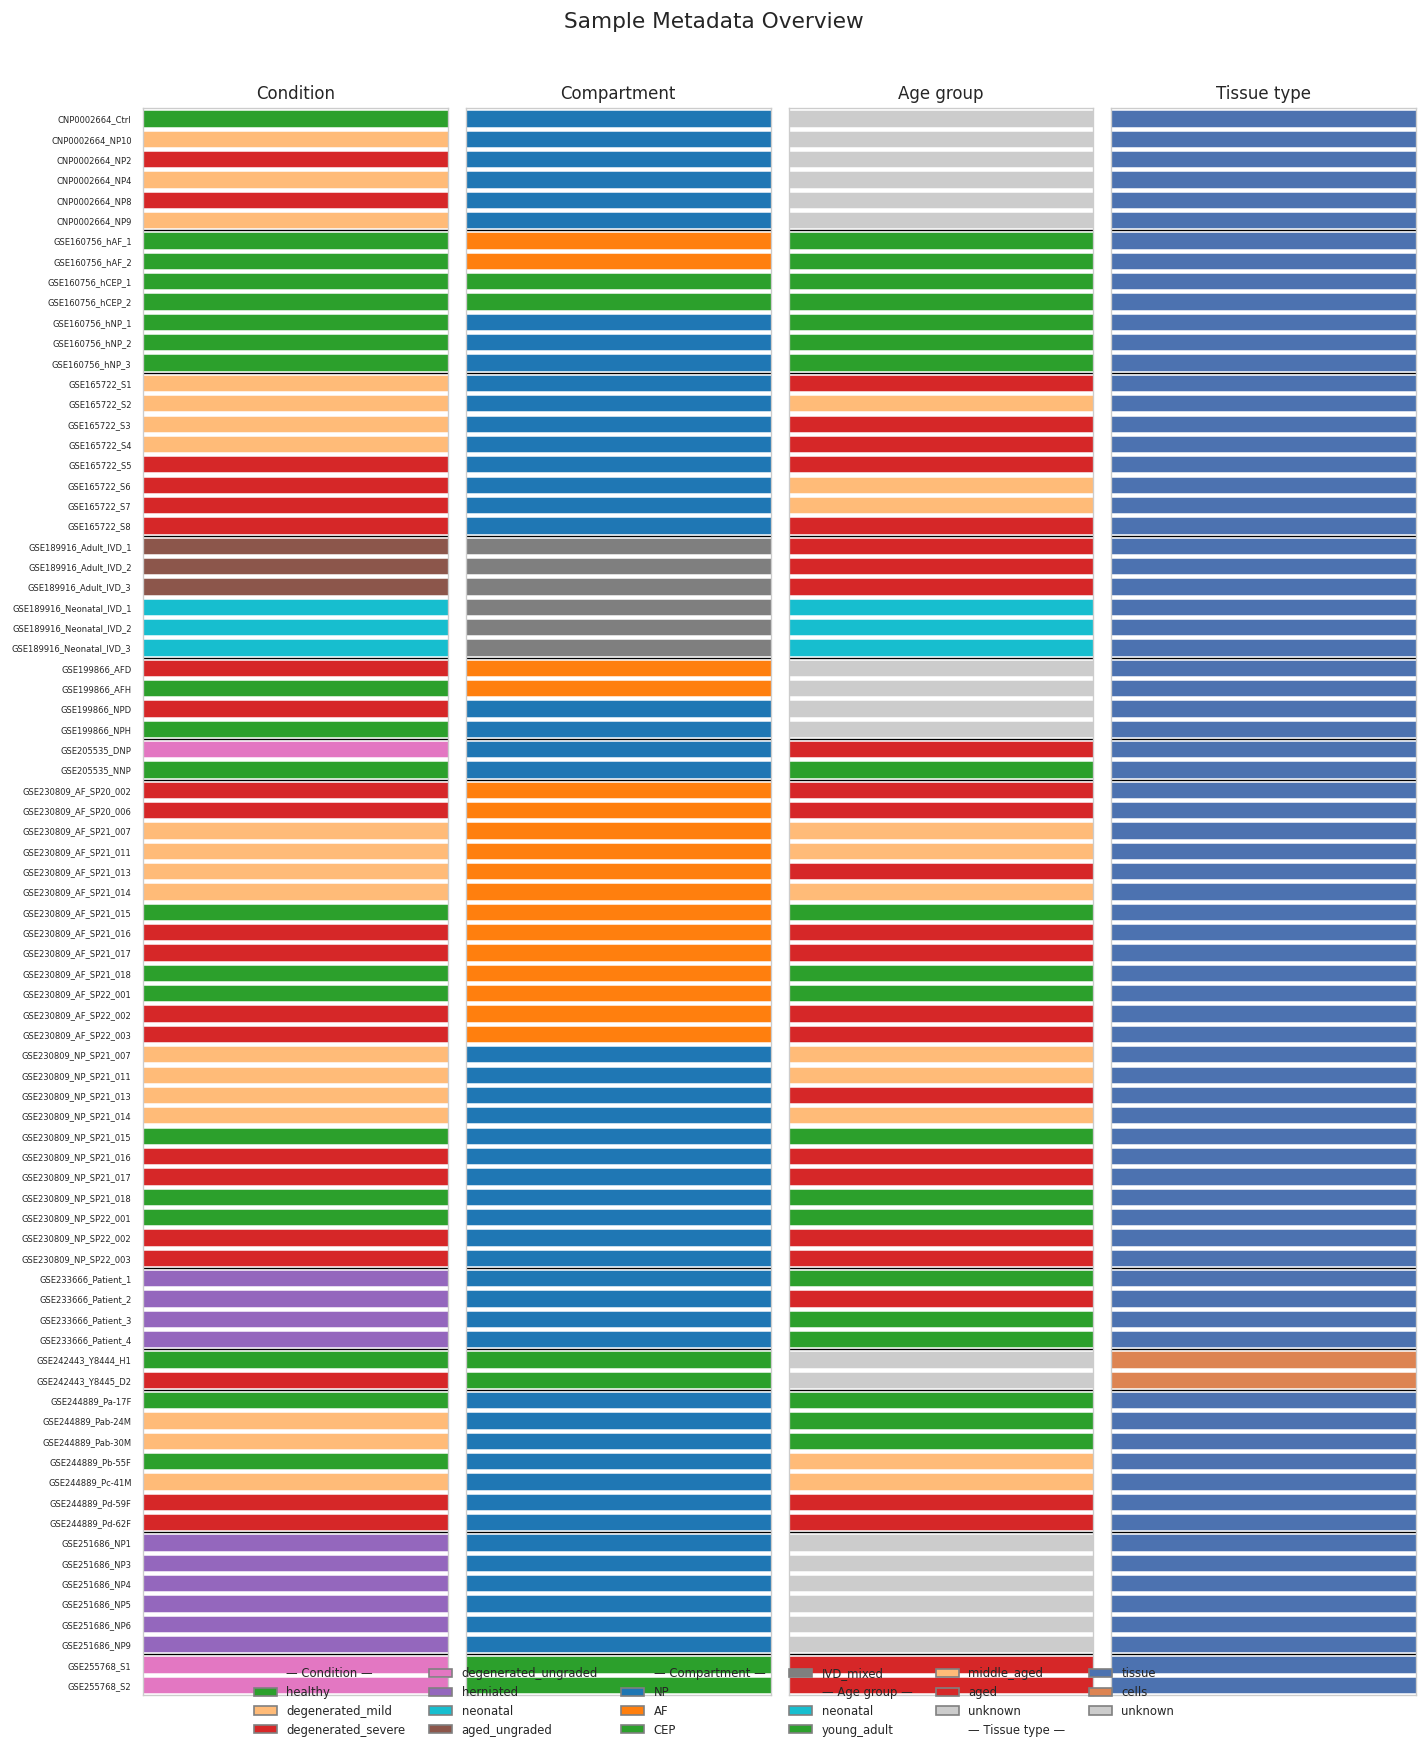

In [3]:
# Sort samples by study then sample_id for visual grouping
meta_sorted = meta.sort_values(['study_accession', 'sample_id']).reset_index(drop=True)

# Define color maps for each attribute
cond_colors = {
    'healthy': '#2ca02c', 'degenerated_mild': '#ffbb78',
    'degenerated_severe': '#d62728', 'degenerated_ungraded': '#e377c2',
    'herniated': '#9467bd', 'neonatal': '#17becf', 'aged_ungraded': '#8c564b',
}
comp_colors = {'NP': '#1f77b4', 'AF': '#ff7f0e', 'CEP': '#2ca02c', 'IVD_mixed': '#7f7f7f'}
age_colors = {
    'neonatal': '#17becf', 'young_adult': '#2ca02c', 'middle_aged': '#ffbb78',
    'aged': '#d62728', 'unknown': '#cccccc',
}
tissue_colors = {'tissue': '#4c72b0', 'cells': '#dd8452', 'unknown': '#cccccc'}

attrs = [
    ('condition_harmonized', 'Condition', cond_colors),
    ('compartment', 'Compartment', comp_colors),
    ('age_group', 'Age group', age_colors),
    ('tissue_or_cells', 'Tissue type', tissue_colors),
]

fig, axes = plt.subplots(1, len(attrs), figsize=(12, max(8, len(meta_sorted) * 0.18)),
                         sharey=True)

y_labels = meta_sorted['sample_id'].values
# Draw study dividers
study_boundaries = []
prev_study = None
for i, study in enumerate(meta_sorted['study_accession']):
    if study != prev_study and prev_study is not None:
        study_boundaries.append(i - 0.5)
    prev_study = study

for col_i, (col, title, cmap) in enumerate(attrs):
    ax = axes[col_i]
    values = meta_sorted[col].values
    numeric = np.array([list(cmap.keys()).index(v) if v in cmap else -1 for v in values])
    colors = [cmap.get(v, '#ffffff') for v in values]

    for j, (c, lbl) in enumerate(zip(colors, values)):
        ax.barh(j, 1, color=c, edgecolor='white', linewidth=0.3)

    ax.set_xlim(0, 1)
    ax.set_ylim(-0.5, len(y_labels) - 0.5)
    ax.invert_yaxis()
    ax.set_xticks([])
    ax.set_title(title, fontsize=10)

    for boundary in study_boundaries:
        ax.axhline(boundary, color='black', linewidth=0.8)

    if col_i == 0:
        ax.set_yticks(range(len(y_labels)))
        ax.set_yticklabels(y_labels, fontsize=5)

# Add legends below the figure
legend_elements = []
for col, title, cmap in attrs:
    legend_elements.append(Patch(facecolor='none', edgecolor='none', label=f'— {title} —'))
    for label, color in cmap.items():
        legend_elements.append(Patch(facecolor=color, edgecolor='gray', label=label))

fig.legend(
    handles=legend_elements, loc='lower center', ncol=6,
    fontsize=7, frameon=False, bbox_to_anchor=(0.5, -0.02),
)
fig.suptitle('Sample Metadata Overview', fontsize=13, y=1.01)
fig.tight_layout()
fig.savefig(FIG_DIR / 'notebook_02_metadata_tiles.png', bbox_inches='tight')
plt.show()

## Age–Degeneration Relationship

Age and disc degeneration are biologically linked — older discs tend to be more
degenerated. But if this relationship is too tight in our data, it becomes a
**confound**: we cannot distinguish age-driven transcriptional changes from
degeneration-driven ones.

The plots below show:
- **Left:** A strip plot of donor age (where reported) grouped by harmonized condition.
  If healthy samples are exclusively young and degenerated samples are exclusively
  old, age and degeneration are confounded.
- **Right:** A mosaic-style count of age group vs. degeneration severity, showing
  how many samples fall into each combination.

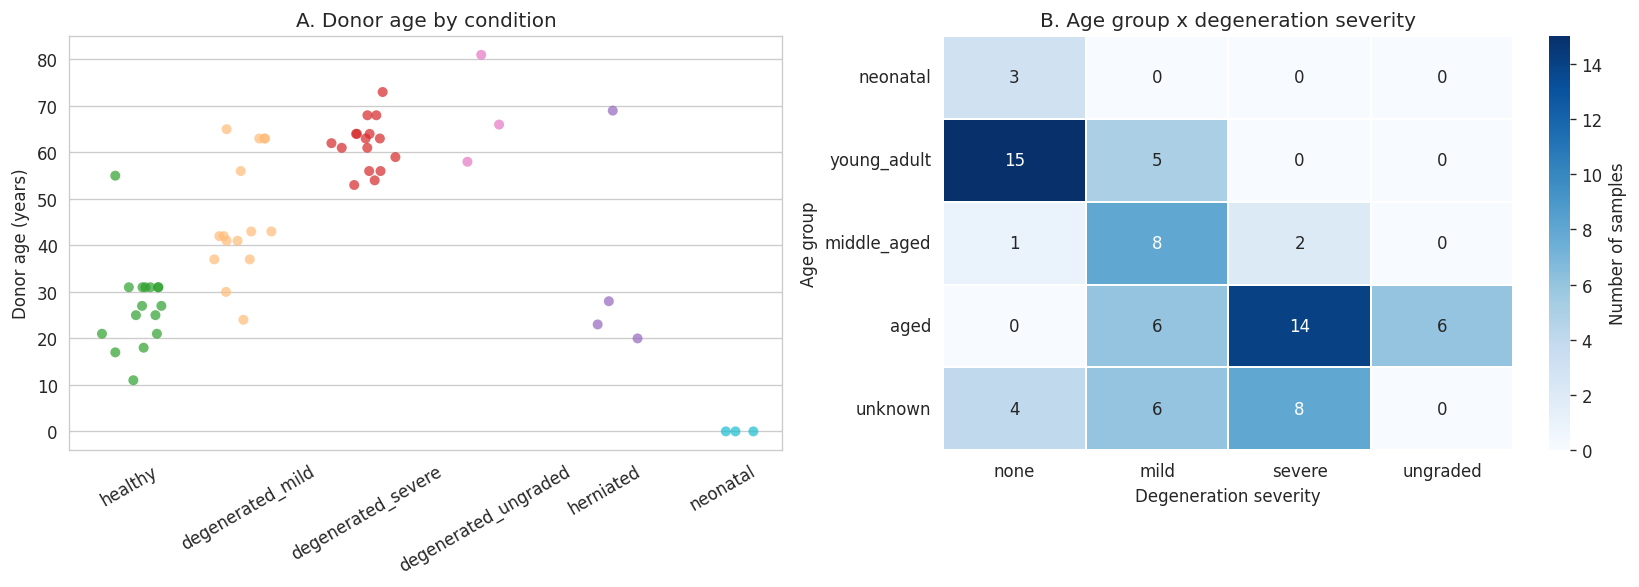

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel A: Age vs condition strip plot
ax = axes[0]
meta_age = meta.dropna(subset=['age_years']).copy()
meta_age['age_years'] = pd.to_numeric(meta_age['age_years'], errors='coerce')
meta_age = meta_age.dropna(subset=['age_years'])

cond_order = ['healthy', 'degenerated_mild', 'degenerated_severe',
              'degenerated_ungraded', 'herniated', 'neonatal', 'aged_ungraded']
cond_present = [c for c in cond_order if c in meta_age['condition_harmonized'].values]

if len(meta_age) > 0:
    sns.stripplot(
        data=meta_age, x='condition_harmonized', y='age_years',
        order=cond_present, palette=cond_colors, jitter=0.3,
        size=6, alpha=0.7, ax=ax,
    )
    ax.set_xlabel('')
    ax.set_ylabel('Donor age (years)')
    ax.set_title('A. Donor age by condition')
    ax.tick_params(axis='x', rotation=30)
else:
    ax.text(0.5, 0.5, 'No age data available', ha='center', va='center', transform=ax.transAxes)

# Panel B: Age group x degeneration severity heatmap
ax = axes[1]
age_order = ['neonatal', 'young_adult', 'middle_aged', 'aged', 'unknown']
sev_order = ['none', 'mild', 'severe', 'ungraded']
age_sev = pd.crosstab(
    meta['age_group'], meta['degeneration_severity']
).reindex(index=age_order, columns=sev_order, fill_value=0)

sns.heatmap(
    age_sev, annot=True, fmt='d', cmap='Blues', linewidths=1, linecolor='white',
    cbar_kws={'label': 'Number of samples'}, ax=ax,
)
ax.set_xlabel('Degeneration severity')
ax.set_ylabel('Age group')
ax.set_title('B. Age group x degeneration severity')
ax.tick_params(axis='y', rotation=0)

fig.tight_layout()
fig.savefig(FIG_DIR / 'notebook_02_age_degeneration.png')
plt.show()

## Confound Identification

Beyond age vs. degeneration, other metadata variables may be confounded. For example:
- If all healthy samples come from one study and one platform, then "healthy vs. degenerated"
  comparisons are confounded by batch and technology.
- If all CEP samples are culture-expanded while all NP samples are fresh tissue,
  compartment comparisons will be confounded by preparation method.

The heatmaps below show cross-tabulations of potentially confounded variable pairs.

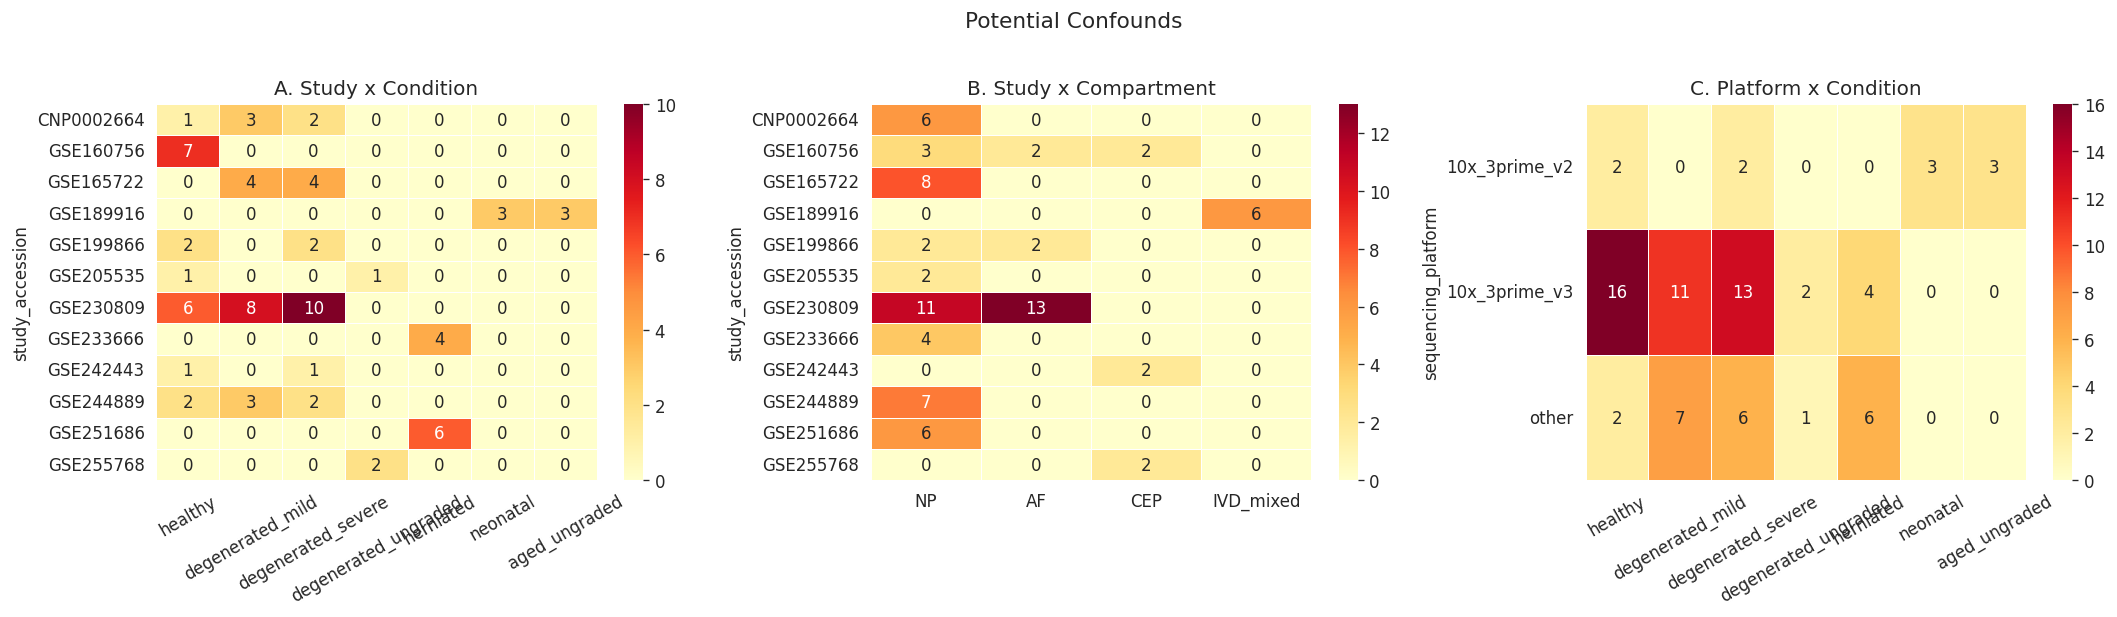

In [5]:
comp_order = ['NP', 'AF', 'CEP', 'IVD_mixed']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# A. Study x Condition
ax = axes[0]
ct1 = pd.crosstab(meta['study_accession'], meta['condition_harmonized'])
ct1 = ct1.reindex(columns=[c for c in cond_order if c in ct1.columns], fill_value=0)
sns.heatmap(ct1, annot=True, fmt='d', cmap='YlOrRd', linewidths=0.5, ax=ax)
ax.set_title('A. Study x Condition')
ax.set_xlabel('')
ax.tick_params(axis='x', rotation=30)
ax.tick_params(axis='y', rotation=0)

# B. Study x Compartment
ax = axes[1]
ct2 = pd.crosstab(meta['study_accession'], meta['compartment'])
comp_order_present = [c for c in comp_order if c in ct2.columns]
ct2 = ct2.reindex(columns=comp_order_present, fill_value=0)
sns.heatmap(ct2, annot=True, fmt='d', cmap='YlOrRd', linewidths=0.5, ax=ax)
ax.set_title('B. Study x Compartment')
ax.set_xlabel('')
ax.tick_params(axis='x', rotation=0)
ax.tick_params(axis='y', rotation=0)

# C. Platform x Condition
ax = axes[2]
ct3 = pd.crosstab(meta['sequencing_platform'], meta['condition_harmonized'])
ct3 = ct3.reindex(columns=[c for c in cond_order if c in ct3.columns], fill_value=0)
sns.heatmap(ct3, annot=True, fmt='d', cmap='YlOrRd', linewidths=0.5, ax=ax)
ax.set_title('C. Platform x Condition')
ax.set_xlabel('')
ax.tick_params(axis='x', rotation=30)
ax.tick_params(axis='y', rotation=0)

fig.suptitle('Potential Confounds', fontsize=13, y=1.02)
fig.tight_layout()
fig.savefig(FIG_DIR / 'notebook_02_confounds.png')
plt.show()

## Sex Distribution

Donor sex is often underreported in IVD studies. The plot below shows how many
samples have reported sex and how the M/F balance looks across conditions.
Strong sex imbalance within a condition group is worth noting, though IVD
degeneration does not have a strong known sex bias.

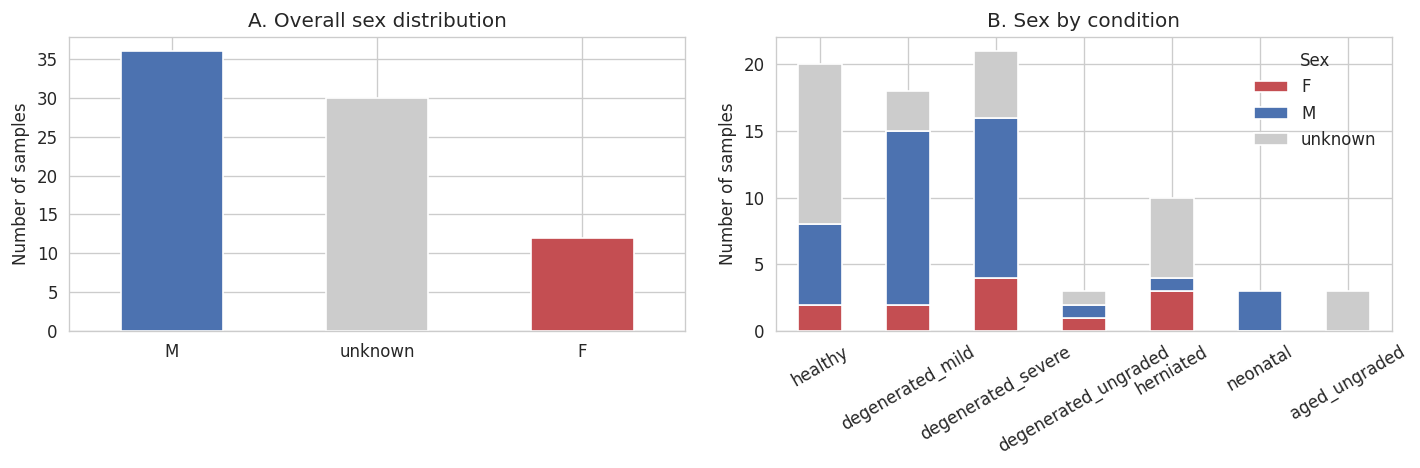

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# A. Overall sex distribution
ax = axes[0]
sex_counts = meta['sex'].value_counts()
sex_colors = {'M': '#4c72b0', 'F': '#c44e52', 'unknown': '#cccccc'}
sex_counts.plot.bar(ax=ax, color=[sex_colors.get(s, '#999') for s in sex_counts.index],
                    edgecolor='white')
ax.set_title('A. Overall sex distribution')
ax.set_ylabel('Number of samples')
ax.set_xlabel('')
ax.tick_params(axis='x', rotation=0)

# B. Sex x Condition
ax = axes[1]
ct_sex = pd.crosstab(meta['sex'], meta['condition_harmonized'])
ct_sex = ct_sex.reindex(columns=[c for c in cond_order if c in ct_sex.columns], fill_value=0)
ct_sex.T.plot.bar(stacked=True, ax=ax,
                  color=[sex_colors.get(s, '#999') for s in ct_sex.index],
                  edgecolor='white')
ax.set_title('B. Sex by condition')
ax.set_ylabel('Number of samples')
ax.set_xlabel('')
ax.tick_params(axis='x', rotation=30)
ax.legend(title='Sex', frameon=False)

fig.tight_layout()
fig.savefig(FIG_DIR / 'notebook_02_sex_distribution.png')
plt.show()

## Harmonization Mapping Reference

For transparency, the table below shows the ontology mappings used to convert
original study-specific terms into the harmonized schema. Each row documents
one mapping decision — these are the interpretive choices that underpin every
downstream comparison.

In [7]:
display(
    onto.style
    .set_caption('Ontology Mappings: Original → Harmonized Terms')
    .hide(axis='index')
)

category,original_term,harmonized_term,notes
condition,healthy,healthy,"No degeneration, Pfirrmann I or Thompson I-II"
condition,healthy young and adult,healthy,"GSE160756: young donors, Pfirrmann I"
condition,non-degenerating,healthy,GSE199866: Thompson I-II disc
condition,normal,healthy,"GSE205535: described as normal, but flagged"
condition,normal control,healthy,CNP0002664: Pfirrmann I
condition,neonatal IVD,neonatal,GSE189916: 6h postnatal tissue
condition,adult IVD >65 no pain,aged_ungraded,"GSE189916: aged, no degeneration grading"
condition,Pfirrmann II,degenerated_mild,Pfirrmann II-III = mild per spec
condition,Pfirrmann III,degenerated_mild,Pfirrmann II-III = mild per spec
condition,Pfirrmann IV,degenerated_severe,Pfirrmann IV-V = severe per spec


## Notes and Caveats

**Key observations from this metadata overview:**

1. **Age–degeneration confounding:** Healthy samples tend to come from younger donors,
   while severely degenerated samples are from older donors. This is an inherent
   limitation of the available data and must be discussed when interpreting
   differential expression results.

2. **Compartment imbalance:** NP is by far the best-represented compartment.
   AF and especially CEP coverage are sparse, limiting compartment-specific analyses.

3. **Sex reporting:** Many studies do not report donor sex, limiting our ability
   to assess sex as a biological variable.

4. **Culture-expanded samples:** GSE242443 (CEP) uses passage-1 culture-expanded cells,
   which may have altered gene expression compared to fresh tissue. This was included
   to improve sparse CEP coverage but should be interpreted with caution.

5. **Platform diversity:** Most datasets use 10x Genomics, but BD Rhapsody, Singleron,
   and other platforms are also represented. Integration must account for platform-specific
   biases.

Full harmonization decisions are documented in `metadata/harmonization_notes.md`.
Figures saved to `results/qc_reports/` with prefix `notebook_02_`.

In [8]:
saved_figures = sorted(FIG_DIR.glob('notebook_02_*.png'))
print('Saved figures:')
for f in saved_figures:
    print(f'  {f.relative_to(BASE)}')

Saved figures:
  results/qc_reports/notebook_02_age_degeneration.png
  results/qc_reports/notebook_02_confounds.png
  results/qc_reports/notebook_02_metadata_tiles.png
  results/qc_reports/notebook_02_sex_distribution.png
